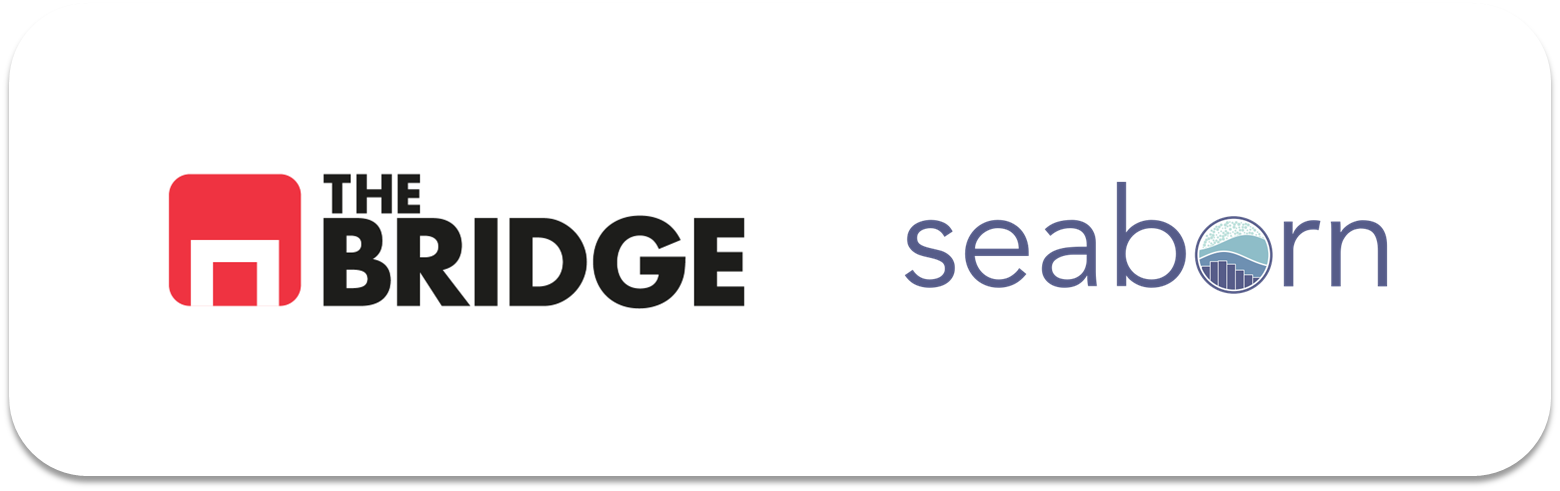

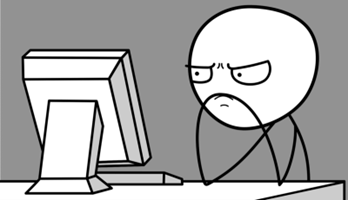

Para ejercitarte y afianzar lo aprendido sobre visualización de datos de una sola variable, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Ejercicio 1

Carga los siguientes datasets que necesitarás para poder hacer el resto de ejercicios:
1. Titanic, "./data/titanic.csv"
2. Bitcoin, "./data/BTC.csv"
3. Viajes, "./data/dataset_viajes_jun23"

En el dataset de Bitcoin, convierte la columna "date" a datetime y luego hazla el índice del dataframe.

In [2]:
df_viajes = pd.read_csv("./data/dataset_viajes_jun23.csv")
df_titanic = pd.read_csv("./data/titanic.csv")
df_bitcoin = pd.read_csv("./data/BTC.csv")

In [3]:
# Convertir la columna de Bitconin "date" en datatime y hacerla íncide

df_bitcoin["fechas"] = pd.to_datetime(df_bitcoin["date"])
df_bitcoin.set_index("fechas", inplace = True)
df_bitcoin.drop("date", axis = 1, inplace = True)
df_bitcoin.head()

,unix,symbol,open,high,low,close,Volume BTC,Volume USD
fechas,,,,,,,,
2022-03-01,1646092800,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
2022-02-28,1646006400,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2022-02-27,1645920000,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
2022-02-26,1645833600,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
2022-02-25,1645747200,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


### Ejercicio 2

Crea una función a la que puedas pasar como argumentos un dataframe y una lista de columnas categóricas y dibuje una matriz de gráficas de 2 columnas y tantas filas como necesite para pintar el diagrama de barras de las frecuencias absolutas de las columnas pasadas como argumento. No hace falta que compruebes que las columnas son categóricas. Y que ponga como título de cada figura "Frecuencias Absolutas de \<nombre de la columna>\. Utiliza Seaborn para dibujar las gráficas y matplotlib para lo que necesites (pero no para dibujar las gráficas)

In [4]:
import math

def matriz_frecuencias_absolutas(df, columnas):
    """
    Dibuja una matriz de gráficos (2 columnas, n filas) con los countplots
    de las columnas categóricas pasadas como argumento.
    """
    
    n = len(columnas)                          # número total de columnas a graficar
    filas = math.ceil(n / 2)                   # número de filas necesarias
    
    fig, axs = plt.subplots(filas, 2, figsize=(12, 4 * filas))
    axs = axs.flatten()                        # aplanamos para indexar fácilmente
    
    for i, col in enumerate(columnas):
        sns.countplot(x=df[col], ax=axs[i])    # gráfico con seaborn
        axs[i].set_title(f"Frecuencias Absolutas de {col}")  # título
        axs[i].set_xlabel(col)
        axs[i].set_ylabel("Frecuencia")
    
    # Si sobran axes (por ejemplo, número impar de columnas), los apagamos
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

### Ejercicio 3

Utiliza la función anterior para pintar las gráficas de frecuencias de las variables categóricas `alive,embark_town,who` del dataset de titanic


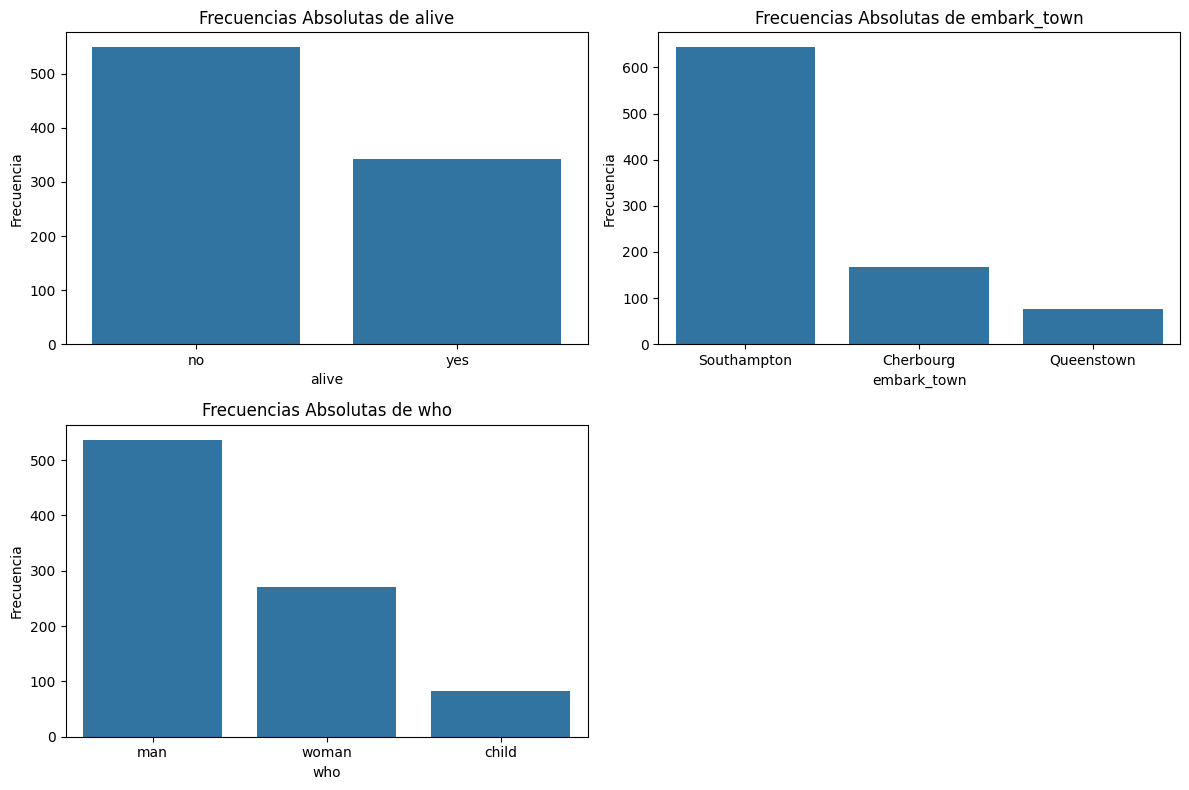

In [5]:
matriz_frecuencias_absolutas(df_titanic, ["alive", "embark_town", "who"])

### Ejercicio 4

Crea una función similar a la del ejercicio 4, pero que esta vez pinte el histograma de una lista de columnas numéricas, añade un argumento para poder indicar el número de bins. Añade también un argumento que permita incluir la función de densidad o no en la figura. De nuevo usa Seaborn para crear las figuras. También debe cumplirse el que pinte cada grafica en una matriz de 2 columnas como mucho y todas las filas que necesites.

In [7]:
def matriz_histogramas(df, columnas, bins=30, kde=False):
    """
    Dibuja una matriz de histogramas (2 columnas, n filas) para las columnas numéricas
    pasadas como argumento. Permite elegir número de bins y activar/desactivar KDE.
    """
    
    n = len(columnas)                    # número total de columnas a graficar
    filas = math.ceil(n / 2)             # número de filas necesarias
    
    fig, axs = plt.subplots(filas, 2, figsize=(12, 4 * filas))
    axs = axs.flatten()                  # aplanamos para indexar fácilmente
    
    for i, col in enumerate(columnas):
        sns.histplot(
            df[col],                     # variable numérica
            bins=bins,                   # número de bins
            kde=kde,                     # incluir o no KDE
            ax=axs[i],                   # subplot correspondiente
            color="steelblue"            # color elegante
        )
        
        axs[i].set_title(f"Histograma de {col}")  # título
        axs[i].set_xlabel(col)
        axs[i].set_ylabel("Frecuencia")
    
    # Si sobran axes (por ejemplo, número impar de columnas), los apagamos
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


### Ejercicio 5

Aplica la función del ejercicio anterior para pintar los histogramas de las columnas "ingresos", "consumo_kg" y "duracion" del dataset de viajes pero aplicando la siguiente lista de bins [10,30,60]. Aunque no seamos muy pro-histrogramas, ¿con cuál las posibles gráficas te quedarías para visualizar los valores de cada variable?

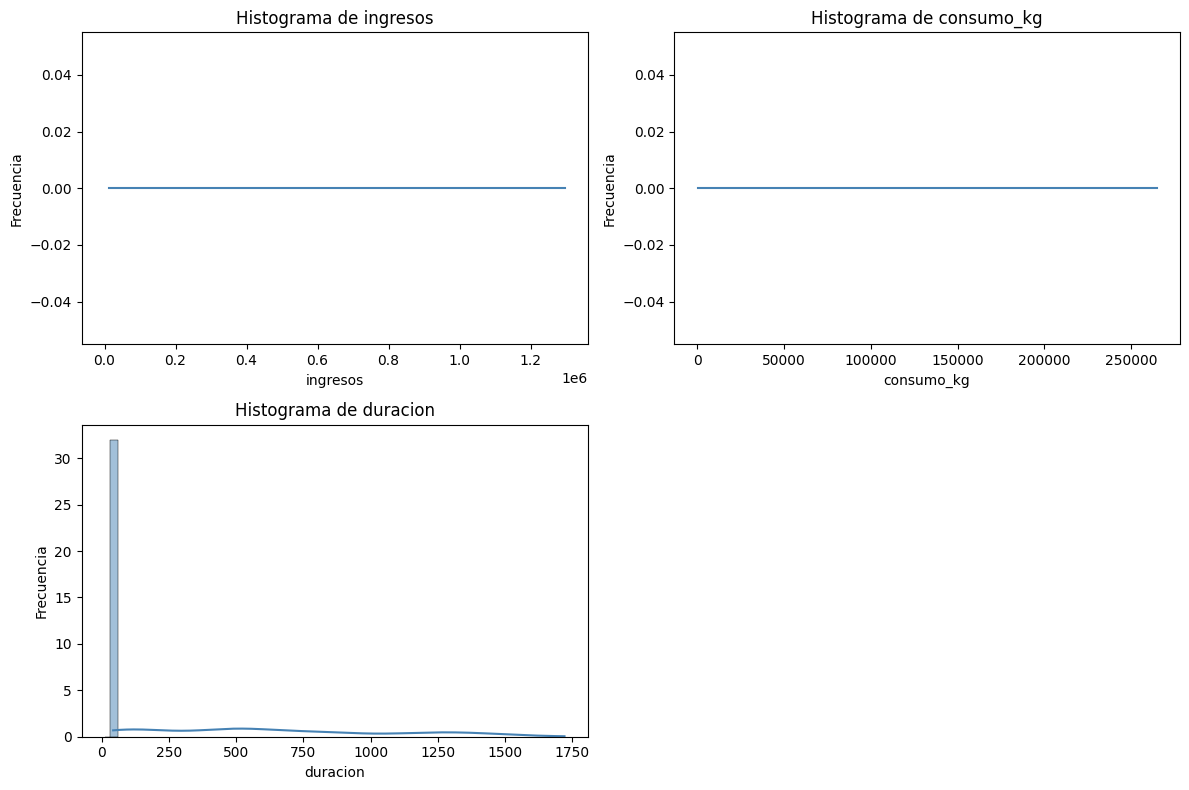

In [11]:
matriz_histogramas( df = df_viajes,
                   columnas = ["ingresos", "consumo_kg", "duracion"], 
                   bins = [10,30,60],
                   kde = True
                   )

### Ejercicio 6

Construye una función a la que puedas pasar un dataframe y una serie de columnas numéricas (que suponemos son series temporales o secuencias) y que pinte cada columna en una sola gráfica (de nuevo en una matriz de 2 columnas como mucho).

In [ ]:
def matriz_series_temporales(df, columnas):
    """
    Dibuja una matriz de gráficos de líneas (2 columnas, n filas) para las columnas numéricas
    pasadas como argumento. Pensado para series temporales o secuencias.
    """
    
    n = len(columnas)                     # número total de columnas a graficar
    filas = math.ceil(n / 2)             # número de filas necesarias
    
    fig, axs = plt.subplots(filas, 2, figsize=(12, 4 * filas))
    axs = axs.flatten()                  # aplanamos para indexar fácilmente
    
    for i, col in enumerate(columnas):
        sns.lineplot(
            x=df.index,                  # eje X: índice (fechas o secuencia)
            y=df[col],                   # eje Y: valores numéricos
            ax=axs[i],                   # subplot correspondiente
            color="darkblue"             # color elegante
        )
        
        axs[i].set_title(f"Evolución de {col}")  # título
        axs[i].set_xlabel("Índice / Tiempo")
        axs[i].set_ylabel(col)
    
    # Si sobran axes (por ejemplo, número impar de columnas), los apagamos
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

### Ejercicio 7

Visualiza las columnas `open`,`close`,`high`,`low` del dataset de Bitcoin. 

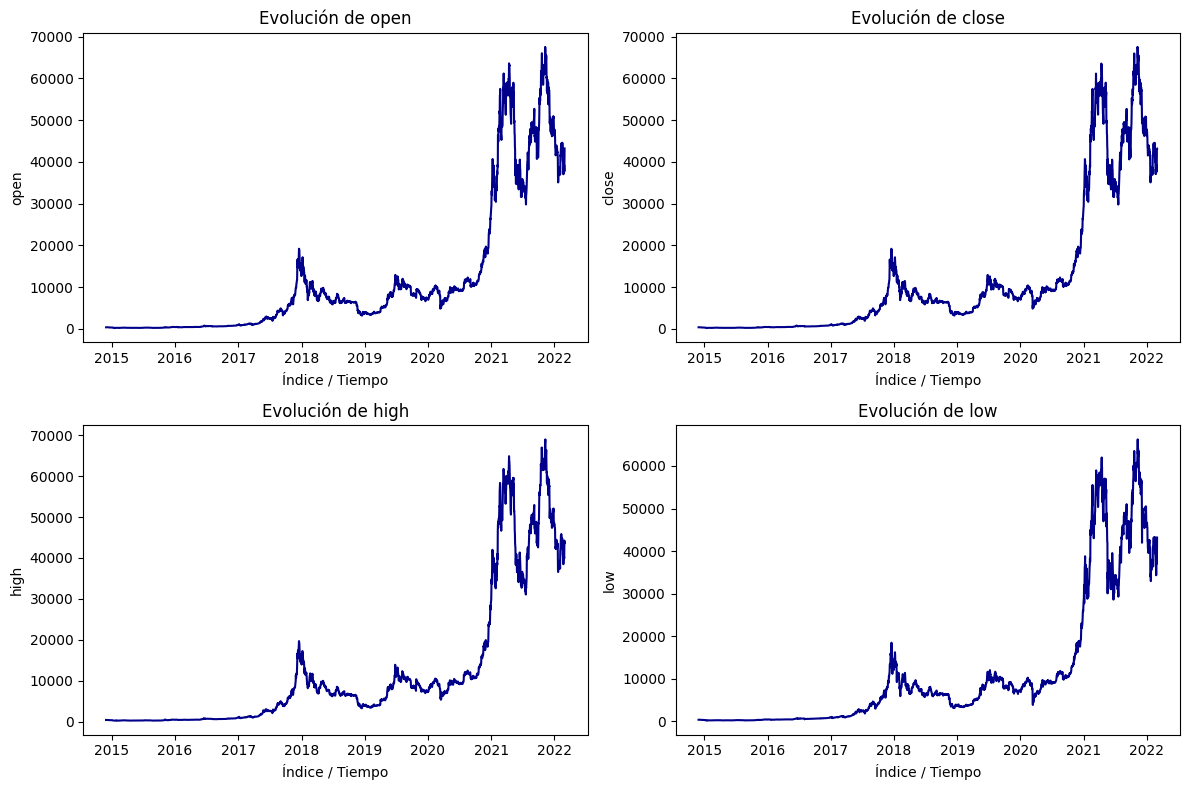

In [13]:
matriz_series_temporales(
    df_bitcoin,
    columnas=["open", "close", "high", "low"]
)


### Ejercicio 8

Añade tres argumentos a la funcion del ejercicio 6. El primero debe permitir pintar una sola gráfica con todas las líneas de evolución juntas y añadir una leyenda. El segundo debe permitir colocar una fecha de inicio y el tercero una fecha de fin. Si no se dan valores a estos argumentos la figura debe contemplarlos todos, si se dan la figura sólo debe mostrar los valores comprendidos entre esas fechas. Supon que la fecha es el índice del DataFrame. De nuevo las gráficas deben estar pintadas con Seaborn.

In [14]:
def matriz_series_temporales(
    df, columnas, 
    todas_juntas=False, 
    fecha_inicio=None, 
    fecha_fin=None
):
    """
    Dibuja series temporales de columnas numéricas.
    
    Parámetros:
    - df: DataFrame con índice de fechas.
    - columnas: lista de columnas numéricas.
    - todas_juntas: si True, dibuja todas las líneas en una sola figura.
    - fecha_inicio: fecha mínima a mostrar (string o datetime).
    - fecha_fin: fecha máxima a mostrar (string o datetime).
    """

    # --- FILTRADO POR FECHAS ---
    df_filtrado = df.copy()

    if fecha_inicio is not None:
        df_filtrado = df_filtrado[df_filtrado.index >= fecha_inicio]

    if fecha_fin is not None:
        df_filtrado = df_filtrado[df_filtrado.index <= fecha_fin]

    # --- CASO 1: TODAS LAS SERIES EN UNA SOLA GRÁFICA ---
    if todas_juntas:
        plt.figure(figsize=(10, 5))

        for col in columnas:
            sns.lineplot(
                x=df_filtrado.index,
                y=df_filtrado[col],
                label=col
            )

        plt.title("Evolución conjunta de las series")
        plt.xlabel("Tiempo")
        plt.ylabel("Valor")
        plt.legend()
        plt.tight_layout()
        plt.show()
        return  # terminamos aquí

    # --- CASO 2: MATRIZ DE SUBPLOTS (2 COLUMNAS) ---
    n = len(columnas)
    filas = math.ceil(n / 2)

    fig, axs = plt.subplots(filas, 2, figsize=(12, 4 * filas))
    axs = axs.flatten()

    for i, col in enumerate(columnas):
        sns.lineplot(
            x=df_filtrado.index,
            y=df_filtrado[col],
            ax=axs[i],
            color="darkblue"
        )

        axs[i].set_title(f"Evolución de {col}")
        axs[i].set_xlabel("Tiempo")
        axs[i].set_ylabel(col)

    # Ocultar axes sobrantes
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    plt.tight_layout()
    plt.show()


### Ejercicio 9

Muestra el periodo más interesante y sólo ese de las variables `open`,`close` (de forma conjunta) del dataset de Bitcoin. Usa la función creada en el ejercicio anterior.

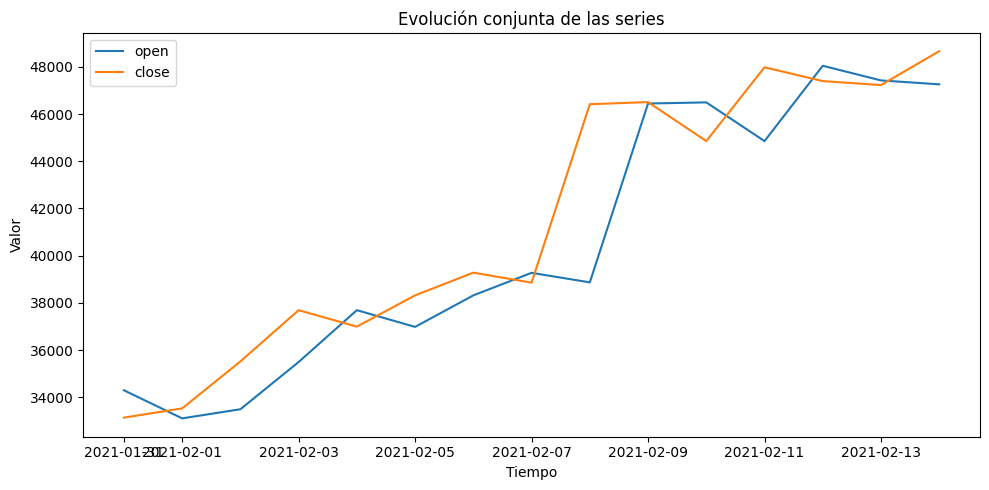

In [ ]:
# 1. Detectar el día con mayor caída
df_bitcoin["variacion"] = df_bitcoin["close"].diff()
dia_mayor_caida = df_bitcoin["variacion"].idxmin()

# 2. Crear un rango de fechas alrededor
fecha_inicio = dia_mayor_caida - pd.Timedelta(days=7)
fecha_fin    = dia_mayor_caida + pd.Timedelta(days=7)

# 3. Llamar a la función del ejercicio 8
matriz_series_temporales(
    df_bitcoin,
    columnas=["open", "close"],
    todas_juntas=True,
    fecha_inicio=fecha_inicio,
    fecha_fin=fecha_fin
)

In [16]:
def periodo_mas_interesante(df, columna="close", ventana=7):
    """
    Detecta automáticamente el periodo más interesante basado en la mayor caída diaria.
    
    Parámetros:
    - df: DataFrame con índice datetime
    - columna: columna numérica sobre la que calcular la caída (por defecto 'close')
    - ventana: días antes y después del evento
    
    Devuelve:
    - fecha_inicio, fecha_fin
    """

    # 1. Variación diaria
    df["variacion"] = df[columna].diff()

    # 2. Día con mayor caída
    dia_mayor_caida = df["variacion"].idxmin()

    # 3. Crear rango alrededor
    fecha_inicio = dia_mayor_caida - pd.Timedelta(days=ventana)
    fecha_fin    = dia_mayor_caida + pd.Timedelta(days=ventana)

    return fecha_inicio, fecha_fin


In [17]:
periodo_mas_interesante(df_bitcoin,
                        columna="close",
                        ventana=7)

(Timestamp('2021-01-31 00:00:00'), Timestamp('2021-02-14 00:00:00'))

In [19]:
fecha_min = df_bitcoin["close"].idxmin()


In [20]:
fecha_min

Timestamp('2015-01-14 00:00:00')